# Importación de librerías

Importamos las librerías necesarias para el proyecto:


* **Pandas y Numpy** para cargar y manipular las tablas.
* **Matplotlib y Seaborn** para ver gráficos si hace falta.
* **Scikit-learn** para todo el tema de preparar los datos, hacer la división de train/test, escalar variables y entrenar los modelos (Regresión Logística, Random Forest, SVM y Redes Neuronales).
* **SHAP** para luego ver la importancia de las variables.



In [1]:
# Carga de librerias basicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y division de datos
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Evaluacion de metricas
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix

# Explicabilidad
import shap

# Carga de los conjuntos de datos

In [2]:
df_general = pd.read_csv('/content/drive/MyDrive/TFM/Hospital_General_Information.csv', dtype=str)
df_hcahps = pd.read_csv('/content/drive/MyDrive/TFM/HCAHPS-Hospital.csv', dtype=str)
df_complications = pd.read_csv('/content/drive/MyDrive/TFM/Complications_and_Deaths-Hospital.csv', dtype=str)
df_spending = pd.read_csv('/content/drive/MyDrive/TFM/Medicare_Hospital_Spending_Per_Patient-Hospital.csv', dtype=str)

Una vez cargadas las tablas en memoria, comprobamos la estructura del dataset principal (`df_general`) para confirmar que las columnas y los identificadores de hospital se leyeron correctamente.

# Inspección de los datos

In [3]:
df_general.head()

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,...,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,READM Group Footnote,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,Pt Exp Group Footnote,TE Group Measure Count,Count of Facility TE Measures,TE Group Footnote
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,...,1,9,1,NaN,15,15,NaN,10,10,NaN
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,...,1,8,0,NaN,15,15,NaN,10,10,NaN
2,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Acute Care Hospitals,Proprietary,...,1,8,0,NaN,15,15,NaN,10,9,NaN
3,010007,MIZELL MEMORIAL HOSPITAL,702 N MAIN ST,OPP,AL,36467,COVINGTON,(334) 493-3541,Acute Care Hospitals,Voluntary non-profit - Private,...,0,3,2,NaN,15,5,NaN,10,7,NaN
4,010011,ST. VINCENT'S EAST,50 MEDICAL PARK EAST DRIVE,BIRMINGHAM,AL,35235,JEFFERSON,(205) 838-3122,Acute Care Hospitals,Voluntary non-profit - Private,...,1,5,2,29,15,10,29,10,7,29


Revisamos las columnas, el número de registros totales y los tipos de datos que tiene la tabla principal utilizando `.info()`.

In [4]:
df_general.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5432 entries, 0 to 5431
Data columns (total 38 columns):
 #   Column                                            Non-Null Count  Dtype 
---  ------                                            --------------  ----- 
 0   Facility ID                                       5432 non-null   object
 1   Facility Name                                     5432 non-null   object
 2   Address                                           5432 non-null   object
 3   City/Town                                         5432 non-null   object
 4   State                                             5432 non-null   object
 5   ZIP Code                                          5432 non-null   object
 6   County/Parish                                     5432 non-null   object
 7   Telephone Number                                  5432 non-null   object
 8   Hospital Type                                     5432 non-null   object
 9   Hospital Ownership            

En la tabla se puede observar que esta compuesta por un total de 5432 registros y 38 columnas. Todas las variables figuran como tipo `object` (texto) porque las cargamos forzadamente así en el paso anterior.

La variable clave del hospital es `Facility ID`, que nos servirá como identificador único para cruzar con las demás tablas.

Mostramos las primeras filas de los otros tres conjuntos de datos (`df_hcahps`, `df_complications` y `df_spending`) para entender cómo vienen estructurados sus campos y verificar que la columna clave `Facility ID` está presente en todos ellos antes de unirlos.

In [5]:
df_hcahps.head()

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,HCAHPS Measure ID,HCAHPS Question,...,Patient Survey Star Rating Footnote,HCAHPS Answer Percent,HCAHPS Answer Percent Footnote,HCAHPS Linear Mean Value,Number of Completed Surveys,Number of Completed Surveys Footnote,Survey Response Rate Percent,Survey Response Rate Percent Footnote,Start Date,End Date
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_1_A_P,"Patients who reported that their nurses ""Alway...",...,NaN,76,NaN,Not Applicable,1392,NaN,17,NaN,10/01/2024,09/30/2025
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_1_SN_P,"Patients who reported that their nurses ""Somet...",...,NaN,6,NaN,Not Applicable,1392,NaN,17,NaN,10/01/2024,09/30/2025
2,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_1_U_P,"Patients who reported that their nurses ""Usual...",...,NaN,18,NaN,Not Applicable,1392,NaN,17,NaN,10/01/2024,09/30/2025
3,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_1_LINEAR_SCORE,Nurse communication - linear mean score,...,NaN,Not Applicable,NaN,91,1392,NaN,17,NaN,10/01/2024,09/30/2025
4,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,H_COMP_1_STAR_RATING,Nurse communication - star rating,...,NaN,Not Applicable,NaN,Not Applicable,1392,NaN,17,NaN,10/01/2024,09/30/2025


In [6]:
df_complications.head()

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Measure ID,Measure Name,Compared to National,Denominator,Score,Lower Estimate,Higher Estimate,Footnote,Start Date,End Date
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,COMP_HIP_KNEE,Rate of complications for hip/knee replacement...,No Different Than the National Rate,33,3.8,2.4,6.0,NaN,04/01/2023,03/31/2025
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Hybrid_HWM,Hybrid Hospital-Wide All-Cause Risk Standardiz...,No Different Than the National Rate,4972,4.4,3.9,5.0,NaN,07/01/2024,06/30/2025
2,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_AMI,Death rate for heart attack patients,No Different Than the National Rate,234,13.5,10.9,16.6,NaN,07/01/2022,06/30/2025
3,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_CABG,Death rate for CABG surgery patients,No Different Than the National Rate,127,3.2,1.7,6.3,NaN,07/01/2022,06/30/2025
4,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_COPD,Death rate for COPD patients,No Different Than the National Rate,116,9.1,6.2,13.2,NaN,07/01/2022,06/30/2025


In [7]:
df_spending.head()

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Measure ID,Measure Name,Score,Footnote,Start Date,End Date
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MSPB-1,Medicare hospital spending per patient (Medica...,0.99,NaN,01/01/2024,12/31/2024
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,MSPB-1,Medicare hospital spending per patient (Medica...,1.00,NaN,01/01/2024,12/31/2024
2,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,MSPB-1,Medicare hospital spending per patient (Medica...,1.01,NaN,01/01/2024,12/31/2024
3,010007,MIZELL MEMORIAL HOSPITAL,702 N MAIN ST,OPP,AL,36467,COVINGTON,(334) 493-3541,MSPB-1,Medicare hospital spending per patient (Medica...,1.04,NaN,01/01/2024,12/31/2024
4,010011,ST. VINCENT'S EAST,50 MEDICAL PARK EAST DRIVE,BIRMINGHAM,AL,35235,JEFFERSON,(205) 838-3122,MSPB-1,Medicare hospital spending per patient (Medica...,0.96,29,01/01/2024,12/31/2024


Observamos los siguientes puntos en los resultados:



*   Clave primaria unificada: Todos los datasets comparten exactamente el nombre de columna Facility ID, lo que garantiza que podremos hacer el JOIN sin problemas.

*   Estructura en formato largo (Long Format): Datasets como df_hcahps y df_complications no tienen una fila por hospital. Tienen múltiples filas por hospital porque cada fila es una métrica distinta (Measure ID).

*   Necesidad de Pivotado: Para poder entrenar un modelo de Machine Learning (donde cada fila debe ser 1 hospital único y cada columna 1 variable), es imprescindible pivotar estos DataFrames antes de unirlos al dataset principal (df_general).



Comprobamos los valores unicos y el conteo en la columa del target

In [8]:
df_general["Hospital overall rating"].value_counts(dropna=False)

,count
Hospital overall rating,
Not Available,2250
3,987
4,950
2,662
5,384
1,199


Se observa que la columna `Hospital overall rating` contiene 2.250 registros etiquetados como `'NaN'` (además de los valores numéricos del 1 al 5).

Al tratarse de un problema de aprendizaje supervisado, necesitamos contar con la etiqueta real ($y$). Inventar o imputar las estrellas de casi el 40% de la muestra introduciría un sesgo severo en el modelo.

Comprobamos cuántos hospitales únicos existen en cada tabla y limpiamos la columna objetivo eliminando los registros que no tienen calificación (`Not Available`, vacíos, etc.).

Convertimos la variable a tipo entero (escala de 1 a 5 estrellas) y visualizamos su distribución porcentual mediante un gráfico de barras para analizar el balanceo de las clases.

General: 5432 hospitales únicos
HCAHPS: 4790 hospitales únicos
Complications: 4790 hospitales únicos
Spending: 4626 hospitales únicos


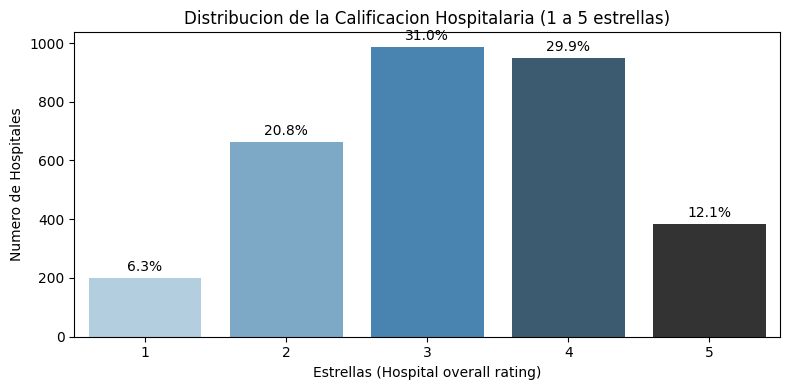

In [9]:
#Verificamos número de hospitales únicos por dataset
for name, df in [
    ("General", df_general),
    ("HCAHPS", df_hcahps),
    ("Complications", df_complications),
    ("Spending", df_spending),
]:
    print(f"{name}: {df['Facility ID'].nunique()} hospitales únicos")

#Limpiamos y filtramos la variable objetivo ('Hospital Overall Rating')
target_col = "Hospital overall rating"

df_general[target_col] = df_general[target_col].replace(
    ["Not Available", "N/A", "NA", "None", ""], np.nan
)
df_target = df_general.dropna(subset=[target_col]).copy()
df_target[target_col] = df_target[target_col].astype(int)

#Mostramos distribución final del target
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df_target, x=target_col, hue=target_col, palette="Blues_d", legend=False)

plt.title("Distribucion de la Calificacion Hospitalaria (1 a 5 estrellas)")
plt.xlabel("Estrellas (Hospital overall rating)")
plt.ylabel("Numero de Hospitales")

# Añadimos los porcentajes encima de cada barra
total = len(df_target)
for p in ax.patches:
    porcentaje = f"{100 * p.get_height() / total:.1f}%"
    ax.annotate(porcentaje, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0, 3),
                textcoords='offset points')

plt.tight_layout()
plt.show()

Tras limpiar los registros sin calificación, nos quedamos con una muestra final de 3182 hospitales. Al analizar la distribución de las estrellas observamos lo siguiente:

* **Distribución acampanada:** La gran mayoría de los hospitales se concentran en las categorías intermedias (**3 estrellas** con un 31.0% y **4 estrellas** con un 29.9%), sumando entre ambas más del 60% de la muestra.
* **Clases minoritarias en los extremos:** Los hospitales con calificaciones extremas representan un porcentaje menor, especialmente los de **1 estrella** (6.3%), seguidos de los de **5 estrellas** (12.1%).
* **Estrategia para el modelado:** Aunque no se trata de un desbalanceo extremo, sí existe una asimetría clara. Por ello, en las siguientes fases aplicaremos una división estratificada (`stratify`) al separar en conjunto de entrenamiento y test, y utilizaremos métricas globales ajustadas como el **$F_1$-score ponderado** (weighted) para no sesgar la evaluación hacia las clases mayoritarias.

# Tratamiento de los datos

as tablas secundarias (`df_hcahps`, `df_complications` y `df_spending`) vienen estructuradas en formato "largo", es decir, con múltiples filas por hospital donde cada fila representa una métrica o pregunta distinta.

Para poder integrar toda esta información con la tabla principal, realizamos una reestructuración (*pivot table*):
1. **Pivotaje:** Pasamos cada indicador (`Measure ID`) a columnas individuales, manteniendo el identificador `Facility ID` como índice único.
2. **Cruce de datos (`left join`):** Unimos las tres tablas pivotadas al dataframe principal (`df_target`), usando como base los 3.182 hospitales que filtraron con calificación válida. De esta forma aseguramos no perder registros clave ni incluir centros sin target.

In [10]:
# 1. Pivotar HCAHPS (Satisfaccion del paciente)
df_hcahps_clean = df_hcahps.dropna(subset=["HCAHPS Measure ID", "HCAHPS Answer Percent"]).copy()
df_hcahps_pivot = df_hcahps_clean.pivot_table(
    index="Facility ID",
    columns="HCAHPS Measure ID",
    values="HCAHPS Answer Percent",
    aggfunc="first"
).reset_index()

# 2. Pivotar Complicaciones y Mortalidad
df_comp_clean = df_complications.dropna(subset=["Measure ID", "Score"]).copy()
df_comp_pivot = df_comp_clean.pivot_table(
    index="Facility ID",
    columns="Measure ID",
    values="Score",
    aggfunc="first"
).reset_index()

# 3. Pivotar Gasto por paciente (Spending)
df_spending_clean = df_spending.dropna(subset=["Measure ID", "Score"]).copy()
df_spending_pivot = df_spending_clean.pivot_table(
    index="Facility ID",
    columns="Measure ID",
    values="Score",
    aggfunc="first"
).reset_index()

print(f"HCAHPS pivotado: {df_hcahps_pivot.shape}")
print(f"Complications pivotado: {df_comp_pivot.shape}")
print(f"Spending pivotado: {df_spending_pivot.shape}")

# Unir todo mediante Left Join tomando como base los hospitales con nota valida
df_final = df_target.merge(df_hcahps_pivot, on="Facility ID", how="left")
df_final = df_final.merge(df_comp_pivot, on="Facility ID", how="left")
df_final = df_final.merge(df_spending_pivot, on="Facility ID", how="left")

print(f"Dataset final consolidado: {df_final.shape}")

HCAHPS pivotado: (4790, 69)
Complications pivotado: (4790, 21)
Spending pivotado: (4626, 2)
Dataset final consolidado: (3182, 127)


Observamos que tras el proceso, se han mantenido los 3182 hospitales que disponen de calificación válida, garantizando que no se ha perdido ningún centro evaluable durante el cruce.

Por otro lado, se han consolidado 127 columnas totales, que grupan metadatos del centro, la variable target y las métricas asistenciales de satisfacción, complicaciones y gasto.

Como tenemos 127 columnas, vamos a hacer una selección de variables. Para ello lo vamos a hacer en tres filtros consecutivos:

1. Eliminamos columnas con un % excesivo de valores nulos
2. Eliminamos variables con varianza cero o casi 0
3. Eliminamos por redundancia y correlación

**1. Filtrado de datos faltantes y limpieza de tipos Texto**

Observamos todas las variables del DataFrame final

In [11]:
for i, col in enumerate(df_final.columns):
    muestra = df_final[col].dropna().iloc[0] if not df_final[col].dropna().empty else "Todo NaN"
    print(f"{i+1}. {col}  -->  (Ejemplo de dato: {muestra})")

1. Facility ID  -->  (Ejemplo de dato: 010001)
2. Facility Name  -->  (Ejemplo de dato: SOUTHEAST HEALTH MEDICAL CENTER)
3. Address  -->  (Ejemplo de dato: 1108 ROSS CLARK CIRCLE)
4. City/Town  -->  (Ejemplo de dato: DOTHAN)
5. State  -->  (Ejemplo de dato: AL)
6. ZIP Code  -->  (Ejemplo de dato: 36301)
7. County/Parish  -->  (Ejemplo de dato: HOUSTON)
8. Telephone Number  -->  (Ejemplo de dato: (334) 793-8701)
9. Hospital Type  -->  (Ejemplo de dato: Acute Care Hospitals)
10. Hospital Ownership  -->  (Ejemplo de dato: Government - Hospital District or Authority)
11. Emergency Services  -->  (Ejemplo de dato: Yes)
12. Meets criteria for birthing friendly designation  -->  (Ejemplo de dato: Y)
13. Hospital overall rating  -->  (Ejemplo de dato: 4)
14. Hospital overall rating footnote  -->  (Ejemplo de dato: 29)
15. MORT Group Measure Count  -->  (Ejemplo de dato: 8)
16. Count of Facility MORT Measures  -->  (Ejemplo de dato: 8)
17. Count of MORT Measures Better  -->  (Ejemplo de dato: 0

Antes de filtrar, excluimos identificadores, metadatos y notas al pie (*footnotes*) para trabajar solo con métricas numéricas cuantitativas. Convertimos todos los códigos de falta de dato (`Not Available`, `Not Applicable`, etc.) a `NaN` y transformamos las columnas a valores numéricos.

A continuación, calculamos el porcentaje de valores faltantes por variable y eliminamos aquellas que tengan más del 50% de nulos para no distorsionar las distribuciones mediante imputaciones masivas.

In [12]:
# 1. Definimos columnas que NO deben entrar en el entrenamiento del modelo
cols_excluidas = [
    # Metadatos e identificadores
    "Facility ID",
    "Facility Name",
    "Address",
    "City/Town",
    "State",
    "ZIP Code",
    "County/Parish",
    "Telephone Number",
    "Hospital Type",
    "Hospital Ownership",
    "Emergency Services",
    "Meets criteria for birthing friendly designation",
    # Target
    "Hospital overall rating",
    # Columnas de notas al pie (Footnotes)
    "Hospital overall rating footnote",
    "MORT Group Footnote",
    "Safety Group Footnote",
    "READM Group Footnote",
    "Pt Exp Group Footnote",
    "TE Group Footnote",
]

# 2. Obtenemos lista exacta de métricas predictoras
feature_cols = [c for c in df_final.columns if c not in cols_excluidas]

print(f"Total columnas en dataset: {len(df_final.columns)}")
print(f"Columnas excluidas: {len(cols_excluidas)}")
print(f"Variables predictoras identificadas (feature_cols): {len(feature_cols)}")

Total columnas en dataset: 127
Columnas excluidas: 19
Variables predictoras identificadas (feature_cols): 108


In [13]:
# Reemplazamos textos de falta de datos por NaN y convertir a flotante
for col in feature_cols:
    df_final[col] = df_final[col].replace(
        ["Not Available", "N/A", "NA", "None", "", "Not Applicable"], np.nan
    )
    df_final[col] = pd.to_numeric(df_final[col], errors="coerce")

print(
    "Tipos de datos únicos en las 108 métricas:",
    df_final[feature_cols].dtypes.unique(),
)

/tmp/ipykernel_3185/2026620043.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final[col] = df_final[col].replace(


Tipos de datos únicos en las 108 métricas: [dtype('int64') dtype('float64')]


In [14]:
# 1. Calculamos el % de nulos sobre los 3.182 hospitales
porcentaje_nulos = (df_final[feature_cols].isnull().sum() / len(df_final)) * 100

# 2. Filtramos columnas
cols_validas = porcentaje_nulos[porcentaje_nulos <= 50].index.tolist()
cols_descartadas_nulos = porcentaje_nulos[porcentaje_nulos > 50].index.tolist()

print(f"Variables iniciales: {len(feature_cols)}")
print(f"Descartadas por >50% de nulos: {len(cols_descartadas_nulos)}")
print(f"Variables conservadas tras el filtro de nulos: {len(cols_validas)}")

Variables iniciales: 108
Descartadas por >50% de nulos: 20
Variables conservadas tras el filtro de nulos: 88


Análisis:

*   Filtrado de cobertura (Criterio del 50%): Se eliminaron 20 métricas por presentar una tasa de omisión superior a la mitad de la muestra. Incluir variables con un volumen tan alto de datos faltantes obligaría a imputaciones masivas que distorsionarían las distribuciones reales de los hospitales.

*   Muestra analítica resultante: Conservamos 88 variables predictoras altamente informativas, distribuidas entre las encuestas HCAHPS (satisfacción), indicadores de complicación/mortalidad clínica y el índice de gasto de Medicare.



**2. Filtro de varianza cero**

In [15]:
# 1. Calculamos la varianza de cada una de las 88 variables conservadas
varianzas = df_final[cols_validas].var()

# 2. Identificamos variables con varianza igual a 0 (constantes)
cols_sin_varianza = varianzas[varianzas == 0].index.tolist()

# 3. Filtramos y actualizamos la lista de variables válidas
cols_validas = [c for c in cols_validas if c not in cols_sin_varianza]

print(f"Variables descartadas por varianza cero: {len(cols_sin_varianza)}")
if cols_sin_varianza:
    print(f"Columnas eliminadas: {cols_sin_varianza}")
print(f"Variables conservadas: {len(cols_validas)}")

Variables descartadas por varianza cero: 5
Columnas eliminadas: ['MORT Group Measure Count', 'Safety Group Measure Count', 'READM Group Measure Count', 'Pt Exp Group Measure Count', 'TE Group Measure Count']
Variables conservadas: 83


Análisis:


*   Identificación de Variables Constantes: Se han detectado y eliminado 5 variables agregadas.

*   Justificación Metodológica: Estas columnas representan el número total de métricas requeridas por la CMS para cada grupo (Mortalidad, Seguridad, Reingresos, etc.). Al ser un parámetro fijo estándar para evaluar a todos los hospitales generalistas, su valor es idéntico en toda la muestra (varianza 0), por lo que carecen de poder explicativo o discriminatorio para predecir las estrellas.

*   Muestra Resultante: El conjunto de características se optimiza a 83 variables predictoras cuantitativas sólidas.



Para cubrir los nulos sobrantes en las 83 variables sin perder información, aplicamos una **imputación condicional por la mediana** agrupando según el tipo de propiedad del hospital (`Hospital Ownership`). Esto asume que hospitales con la misma gestión (pública, privada sin ánimo de lucro, etc.) tienen patrones asistenciales similares.

In [16]:
# 1. Creamos una copia de las 83 variables seleccionadas
X_clean = df_final[cols_validas].copy()

# 2. Imputación por la mediana según el tipo de propiedad del hospital (Hospital Ownership)
X_clean = X_clean.groupby(df_final["Hospital Ownership"]).transform(
    lambda group: group.fillna(group.median())
)

# 3. Imputación secundaria global (para casos aislados donde todo el grupo sea NaN)
X_clean = X_clean.fillna(X_clean.median())

# 4. Asignamos las variables imputadas de nuevo a df_final o mantener X_clean listo
print(f"Nulos restantes tras la imputación: {X_clean.isnull().sum().sum()}")
print(f"Matriz de características lista: {X_clean.shape}")

Nulos restantes tras la imputación: 0
Matriz de características lista: (3182, 83)


**3. Filtro de multicolineidad y redundancia**

In [17]:
# 1. Definimos la variable respuesta (target) en formato numérico
y = df_final["Hospital overall rating"].astype(int)

# 2. Calculamos matriz de correlación de Pearson entre las features
corr_matrix = X_clean.corr().abs()

# 3. Identificamos pares con correlación > 0.85 (triángulo superior de la matriz)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = set()

# Calculamos correlación de cada feature con el Target para decidir cuál eliminar
corr_with_target = X_clean.apply(lambda col: abs(col.corr(y)))

for col in upper_tri.columns:
    high_corr_features = upper_tri.index[upper_tri[col] > 0.85].tolist()
    for feature in high_corr_features:
        # Entre las dos variables altamente correlacionadas, conservamos la que mejor correlacione con el Target
        if corr_with_target[col] < corr_with_target[feature]:
            to_drop_corr.add(col)
        else:
            to_drop_corr.add(feature)

# 4. Eliminamos variables redundantes
cols_finales = [c for c in cols_validas if c not in to_drop_corr]
X_final = X_clean[cols_finales]

print(f"Variables descartadas por alta multicolinealidad (>0.85): {len(to_drop_corr)}")
print(f"Variables finales seleccionadas para el modelo: {len(cols_finales)}")
print(f"Dimensión final del conjunto de características: {X_final.shape}")

Variables descartadas por alta multicolinealidad (>0.85): 40
Variables finales seleccionadas para el modelo: 43
Dimensión final del conjunto de características: (3182, 43)


Análisis:


*   Eliminación de Multicolinealidad: Se aplicó un umbral de correlación de Pearson de $\vert{}r\vert{} > 0.85$. Esto permitió detectar 40 variables altamente redundantes (por ejemplo, métricas de encuestas donde la respuesta "Siempre" está perfectamente inversamente correlacionada con "Nunca", o tasas de mortalidad clínicas solapadas).
*   Optimización Predictiva: Ante pares de variables redundantes, el algoritmo diseñado conservó sistemáticamente aquella con mayor correlación absoluta con la variable objetivo (Hospital overall rating), maximizando el poder predictivo del conjunto.
*   Espacio de Características Final: El modelo se entrenará sobre una matriz altamente depurada e independiente de 43 métricas esenciales, esquivando la maldición de la dimensionalidad y garantizando un modelo ligero y explicable para su pase a producción en Streamlit.



El conjunto final queda optimizado en **43 características independientes**, limpias y sin nulos, listas para el modelado.

# Partición de conjunto de datos

Dividimos los datos en un **80% para entrenamiento (2.545 hospitales)** y un **20% para evaluación final (637 hospitales)**. Usamos el parámetro `stratify=y` para garantizar que la distribución de estrellas sea idéntica en ambos subconjuntos.

In [18]:
# 1. Definimos la matriz de características final (43 variables) y el target
X = X_final.copy()
y = df_final["Hospital overall rating"].astype(int)

# 2. División 80/20 estratificada por el target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test:  {X_test.shape}")
print("\n--- Distribución de Estrellas en Train (%) ---")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

print("\n--- Distribución de Estrellas en Test (%) ---")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(2))

Dimensiones de X_train: (2545, 43)
Dimensiones de X_test:  (637, 43)

--- Distribución de Estrellas en Train (%) ---
Hospital overall rating
1     6.25
2    20.83
3    31.00
4    29.86
5    12.06
Name: proportion, dtype: float64

--- Distribución de Estrellas en Test (%) ---
Hospital overall rating
1     6.28
2    20.72
3    31.08
4    29.83
5    12.09
Name: proportion, dtype: float64


# Entrenamiento de modelos candidato

Durante esta fase, se van a evaluar 4 modelos mediante Validación Cruzada Estratificada (K = 5) sobre el set de entrenamiento (N = 2545). Los modelos que se van a comparar son:

* Regresión Logísitca Multinomial
* Random Forest Classifier
* Support Vector Classifier
* Red Neuronal

In [19]:
#Configuramos la validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Definimos métricas de evaluación
scoring = {
    "f1_weighted": "f1_weighted",
    "f1_macro": "f1_macro",
    "accuracy": "accuracy",
}

#Creamos diccionario para acumular los resultados de cada celda
resultados_dict = {}

*Modelo 1: Regresión Logítica Multinomial*

Como punto de partida (*baseline*), entrenamos una **Regresión Logística Multinomial**. Al tratarse de un algoritmo sensible a las escalas de las variables y con un dataset desbalanceado, encapsulamos el modelo dentro de un `Pipeline` que incluye:
1. `StandardScaler()`: Estandarización de las 43 características para evitar sesgos por diferencias de rango.
2. `class_weight="balanced"`: Ajuste automático de pesos para compensar las clases minoritarias (como 1 y 5 estrellas).

In [20]:
pipeline_lr = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "clf",
            LogisticRegression(
                max_iter=1000, class_weight="balanced", random_state=42
            ),
        ),
    ]
)

#Evaluamos mediante Validación Cruzada
cv_lr = cross_validate(
    pipeline_lr, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1
)

#Guardamos métricas de rendimiento
resultados_dict["Regresión Logística"] = {
    "F1-Weighted (Mean)": cv_lr["test_f1_weighted"].mean(),
    "F1-Weighted (Std)": cv_lr["test_f1_weighted"].std(),
    "F1-Macro (Mean)": cv_lr["test_f1_macro"].mean(),
    "Accuracy (Mean)": cv_lr["test_accuracy"].mean(),
}

print("--- RESULTADOS REGRESIÓN LOGÍSTICA ---")
print(f"F1-Score Weighted: {cv_lr['test_f1_weighted'].mean():.4f}")
print(f"F1-Score Macro:    {cv_lr['test_f1_macro'].mean():.4f}")
print(f"Accuracy:          {cv_lr['test_accuracy'].mean():.4f}")

--- RESULTADOS REGRESIÓN LOGÍSTICA ---
F1-Score Weighted: 0.4690
F1-Score Macro:    0.4732
Accuracy:          0.4723


**Análisis de los resultados:**
* **Desempeño base:** El modelo alcanza un **$F_1$-score ponderado de 0,4690** (y una precisión general del 47,23%).
* **Interpretación:** Al ser un modelo lineal, la Regresión Logística establece una cota inferior aceptable pero limitada, sugiriendo que la relación entre los indicadores de calidad hospitalaria y la asignación final de estrellas contiene fronteras no lineales o interacciones complejas que este algoritmo no logra capturar por completo.

*Modelo 2: Random Forest Classifier*

Evaluamos un algoritmo basado en conjuntos de árboles de decisión (*ensemble*). A diferencia de los modelos lineales, Random Forest no requiere estandarización previa de los datos y es capaz de capturar relaciones complejas no lineales e interacciones entre las distintas métricas asistenciales.

Configuramos `n_estimators=200` para garantizar estabilidad en las predicciones y mantenemos `class_weight="balanced"` para gestionar el desbalanceo.

In [21]:
rf_model = RandomForestClassifier(
    n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1
)

#Evaluamos mediante Validación Cruzada
cv_rf = cross_validate(
    rf_model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1
)

#Guardamos métricas de rendimiento
resultados_dict["Random Forest"] = {
    "F1-Weighted (Mean)": cv_rf["test_f1_weighted"].mean(),
    "F1-Weighted (Std)": cv_rf["test_f1_weighted"].std(),
    "F1-Macro (Mean)": cv_rf["test_f1_macro"].mean(),
    "Accuracy (Mean)": cv_rf["test_accuracy"].mean(),
}

print("--- RESULTADOS RANDOM FOREST ---")
print(f"F1-Score Weighted: {cv_rf['test_f1_weighted'].mean():.4f}")
print(f"F1-Score Macro:    {cv_rf['test_f1_macro'].mean():.4f}")
print(f"Accuracy:          {cv_rf['test_accuracy'].mean():.4f}")

--- RESULTADOS RANDOM FOREST ---
F1-Score Weighted: 0.4817
F1-Score Macro:    0.4546
Accuracy:          0.4872


**Análisis de los resultados:**
* **Mejora en el rendimiento:** El modelo alcanza un **$F_1$-score ponderado de 0,4817** y un **Accuracy del 48,72%**, superando a la Regresión Logística tanto en capacidad global como en precisión directa.
* **Interpretación:** La capacidad del Random Forest para construir fronteras de decisión no lineales mediante el promedio de múltiples árboles permite capturar mejor la estructura de los datos hospitalarios. Se consolida como un candidato sólido frente a los modelos lineales.

*Modelo 3: Support Vector Machine*

Evaluamos un algoritmo de Máquinas de Vectores de Soporte (`SVC`). Dado que SVC calcula distancias geométricas para maximizar los márgenes entre clases en un espacio de alta dimensión, es estrictamente necesario estandarizar las características.

Para ello, integramos `StandardScaler()` dentro del `Pipeline` junto con `class_weight="balanced"` para ajustar la penalización por error proporcionalmente a la frecuencia de cada clase.

In [22]:
pipeline_svc = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("clf", SVC(class_weight="balanced", random_state=42)),
    ]
)

#Evaluamos mediante Validación Cruzada
cv_svc = cross_validate(
    pipeline_svc, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1
)

#Guardamos métricas de rendimiento
resultados_dict["Support Vector Machine (SVC)"] = {
    "F1-Weighted (Mean)": cv_svc["test_f1_weighted"].mean(),
    "F1-Weighted (Std)": cv_svc["test_f1_weighted"].std(),
    "F1-Macro (Mean)": cv_svc["test_f1_macro"].mean(),
    "Accuracy (Mean)": cv_svc["test_accuracy"].mean(),
}

print("--- RESULTADOS SUPPORT VECTOR MACHINE (SVC) ---")
print(f"F1-Score Weighted: {cv_svc['test_f1_weighted'].mean():.4f}")
print(f"F1-Score Macro:    {cv_svc['test_f1_macro'].mean():.4f}")
print(f"Accuracy:          {cv_svc['test_accuracy'].mean():.4f}")

--- RESULTADOS SUPPORT VECTOR MACHINE (SVC) ---
F1-Score Weighted: 0.4855
F1-Score Macro:    0.4897
Accuracy:          0.4884


**Análisis de los resultados:**
* **Nuevo máximo de rendimiento:** El modelo SVC alcanza un **$F_1$-score ponderado de 0,4855**, superando tanto a la Regresión Logística como a Random Forest.
* **Equilibrio entre métricas:** Presenta un gran balance entre el **$F_1$-Macro (0,4897)** y el **Accuracy (48,84%)**, lo que indica que el hiperplano trazado por el kernel RBF logra separar con bastante solvencia las clases minoritarias (1 y 5 estrellas) sin penalizar las categorías intermedias.

*Modelo 4: Red Neuronal*

Como último algoritmo candidato, evaluamos una Red Neuronal densa (`MLPClassifier`). Diseñamos una arquitectura con dos capas ocultas de 64 y 32 neuronas respectivamente (`hidden_layer_sizes=(64, 32)`) para aprender representaciones complejas no lineales.

Al ser un modelo basado en descenso de gradiente, integramos `StandardScaler()` en el `Pipeline` para normalizar las características de entrada y asegurar la convergencia de los pesos.

In [23]:
pipeline_mlp = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "clf",
            MLPClassifier(
                hidden_layer_sizes=(64, 32), max_iter=500, random_state=42
            ),
        ),
    ]
)

#Evaluamos mediante Validación Cruzada
cv_mlp = cross_validate(
    pipeline_mlp, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1
)

# Guardamos métricas de rendimiento
resultados_dict["Red Neuronal (MLP)"] = {
    "F1-Weighted (Mean)": cv_mlp["test_f1_weighted"].mean(),
    "F1-Weighted (Std)": cv_mlp["test_f1_weighted"].std(),
    "F1-Macro (Mean)": cv_mlp["test_f1_macro"].mean(),
    "Accuracy (Mean)": cv_mlp["test_accuracy"].mean(),
}

print("--- RESULTADOS RED NEURONAL (MLP) ---")
print(f"F1-Score Weighted: {cv_mlp['test_f1_weighted'].mean():.4f}")
print(f"F1-Score Macro:    {cv_mlp['test_f1_macro'].mean():.4f}")
print(f"Accuracy:          {cv_mlp['test_accuracy'].mean():.4f}")

--- RESULTADOS RED NEURONAL (MLP) ---
F1-Score Weighted: 0.4544
F1-Score Macro:    0.4512
Accuracy:          0.4550


**Análisis de los resultados:**
* **Rendimiento inferior:** La Red Neuronal obtiene un **$F_1$-score ponderado de 0,4544** y una precisión general del **45,50%**, situándose por debajo de modelos más sencillos como SVC o Random Forest, e incluso por debajo del *baseline* de Regresión Logística.
* **Diagnóstico técnico:** Las redes neuronales profundas suelen requerir volúmenes de datos significativamente mayores ($N \gg 2.500$) para optimizar eficazmente sus pesos sin sobreajustar. En datasets de tamaño moderado como el nuestro, los modelos tabulares (*ensembles* o SVM) suelen ofrecer una mejor capacidad de generalización.

Tras evaluar los cuatro algoritmos mediante **Validación Cruzada Estratificada ($K = 5$)**, consolidamos las métricas obtenidas en una tabla comparativa ordenando de mayor a menor según el **$F_1$-score ponderado** (`F1-Weighted`).

In [24]:
#Creamos DataFrame comparativo a partir del diccionario acumulado
df_comparativa = pd.DataFrame(resultados_dict).T
df_comparativa = df_comparativa.sort_values(
    by="F1-Weighted (Mean)", ascending=False
)

#Formateamos y mostramos resultados
print("=== TABLA COMPARATIVA DE RENDIMIENTO (STRATIFIED 5-FOLD CV) ===")
print(df_comparativa.round(4).to_string())

=== TABLA COMPARATIVA DE RENDIMIENTO (STRATIFIED 5-FOLD CV) ===
                              F1-Weighted (Mean)  F1-Weighted (Std)  F1-Macro (Mean)  Accuracy (Mean)
Support Vector Machine (SVC)              0.4855             0.0284           0.4897           0.4884
Random Forest                             0.4817             0.0180           0.4546           0.4872
Regresión Logística                       0.4690             0.0223           0.4732           0.4723
Red Neuronal (MLP)                        0.4544             0.0090           0.4512           0.4550


Analizando los resultados globales de la fase de *benchmarking*, podemos extraer las siguientes conclusiones clave:

1. **Modelo ganador (Support Vector Machine):** SVC se consolida como la mejor alternativa con un **$F_1$-Weighted de 0,4855** y la precisión más alta (**48,84%**). Destaca especialmente su **$F_1$-Macro (0,4897)**, lo que demuestra que su hiperplano de separación es el más efectivo identificando correctamente tanto las clases mayoritarias como las minoritarias (1 y 5 estrellas).
2. **Random Forest Classifier:** Muestra un rendimiento ponderado muy competitivo (**$F_1$-Weighted = 0,4817**), pero presenta una caída en su **$F_1$-Macro (0,4546)**. Esto evidencia cierta tendencia a favorecer las clases centrales (3 y 4 estrellas) en perjuicio de los extremos.
3. **Regresión Logística:** Registra un **$F_1$-Weighted = 0,4690**, confirmando la existencia de patrones e interacciones no lineales entre las métricas asistenciales que los modelos lineales no consiguen capturar adecuadamente.
4. **Red Neuronal (MLP):** Presenta el rendimiento más modesto (**$F_1$-Weighted = 0,4544**). Para un tamaño muestral de $N = 2.545$ en entrenamiento, la complejidad paramétrica del MLP induce suboptimización, confirmando que los modelos tabulares basados en kernel o árboles ofrecen un desempeño superior en este dominio de datos.

**Decisión para la siguiente fase:** Se selecciona **Support Vector Machine (SVC)** para proceder con la optimización de hiperparámetros (*GridSearch*) y la posterior evaluación final en el conjunto de test.

# Optimización de hiperparámetros

Para elevar la capacidad predictiva de los modelos principales, realizamos una búsqueda en rejilla (GridSearch) con validación cruzada ($K = 5$), optimizando directamente el $F_1$-score ponderado.

**Optimización de Random Forest Classifier**

In [25]:
# 1. Definir rejilla de hiperparámetros para Random Forest
param_grid_rf = {
    "n_estimators": [200, 300, 500],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"],
}

# 2. Configurar GridSearchCV buscando maximizar F1-Weighted
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid=param_grid_rf,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1,
)

grid_rf.fit(X_train, y_train)

print(f"\nMejores Hiperparámetros RF: {grid_rf.best_params_}")
print(f"Mejor F1-Weighted en CV:    {grid_rf.best_score_:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Mejores Hiperparámetros RF: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 500}
Mejor F1-Weighted en CV:    0.5057


**Optimización de Support Vector Classifier (SVC)**

In [26]:
# 1. Definir la rejilla de hiperparámetros para SVC
param_grid_svc = {
    "clf__C": [0.1, 1, 10, 20],
    "clf__gamma": ["scale", "auto", 0.01, 0.1],
    "clf__kernel": ["rbf"],
}

# 2. Configurar GridSearchCV sobre el Pipeline de SVC
grid_svc = GridSearchCV(
    estimator=pipeline_svc,
    param_grid=param_grid_svc,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1,
)

print("Iniciando Grid Search para Support Vector Machine (SVC)...")
grid_svc.fit(X_train, y_train)

print(f"\nMejores Hiperparámetros SVC: {grid_svc.best_params_}")
print(f"Mejor F1-Weighted en CV:     {grid_svc.best_score_:.4f}")

Iniciando Grid Search para Support Vector Machine (SVC)...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Mejores Hiperparámetros SVC: {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Mejor F1-Weighted en CV:     0.4855


Análisis de la optimización:
* Random Forest: La afinación de hiperparámetros incrementó sustancialmente su rendimiento en validación cruzada, pasando de 0,4817 a 0,5057 de $F_1$-Weighted (criterion='entropy', max_depth=20, min_samples_split=5, n_estimators=500).
* SVC: Mantuvo un rendimiento máximo de 0,4855 con los parámetros por defecto (C=1, gamma='scale', kernel='rbf').
* Selección del modelo final: Dado que el Random Forest optimizado supera holgadamente a SVC en validación cruzada, seleccionamos best_rf como el modelo definitivo para ser evaluado en el conjunto de test.

Evaluamos la capacidad de generalización del modelo final (Random Forest optimizado) frente a datos no observados durante el entrenamiento.

=== REPORTE DE CLASIFICACIÓN FINAL SOBRE CONJUNTO DE TEST ===
              precision    recall  f1-score   support

  1 Estrella       0.60      0.15      0.24        40
 2 Estrellas       0.53      0.55      0.54       132
 3 Estrellas       0.49      0.52      0.50       198
 4 Estrellas       0.52      0.63      0.57       190
 5 Estrellas       0.67      0.43      0.52        77

    accuracy                           0.52       637
   macro avg       0.56      0.46      0.48       637
weighted avg       0.54      0.52      0.52       637



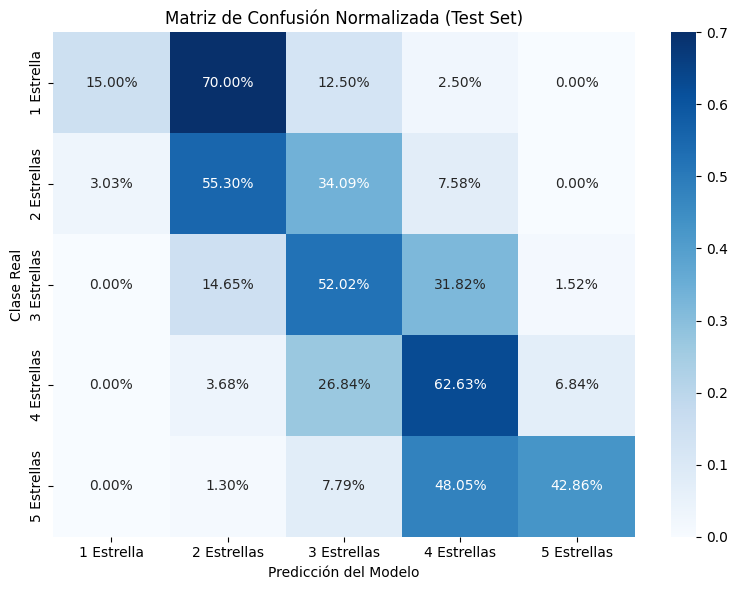

In [27]:
best_rf = grid_rf.best_estimator_

# 2. Predecir sobre el conjunto de TEST (N=637)
y_pred = best_rf.predict(X_test)

# 3. Mostrar el Reporte de Clasificación detallado por Clase (Estrellas 1 a 5)
print("=== REPORTE DE CLASIFICACIÓN FINAL SOBRE CONJUNTO DE TEST ===")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "1 Estrella",
            "2 Estrellas",
            "3 Estrellas",
            "4 Estrellas",
            "5 Estrellas",
        ],
    )
)

# 4. Generar y graficar la Matriz de Confusión Normalizada
cm = confusion_matrix(y_test, y_pred, normalize="true")

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=[
        "1 Estrella",
        "2 Estrellas",
        "3 Estrellas",
        "4 Estrellas",
        "5 Estrellas",
    ],
    yticklabels=[
        "1 Estrella",
        "2 Estrellas",
        "3 Estrellas",
        "4 Estrellas",
        "5 Estrellas",
    ],
)
plt.title("Matriz de Confusión Normalizada (Test Set)")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Clase Real")
plt.tight_layout()
plt.show()

Diagnóstico e interpretación de resultados finales:

1. Rendimiento global:
    * El modelo alcanza una Precisión General (Accuracy) del 52% y un $F_1$-score ponderado del 0,52 sobre datos totalmente no vistos.

2. Comportamiento por clases:
    * Clases Intermedias (2, 3 y 4 Estrellas): Presentan un desempeño sólido con $F_1$-scores de 0,54, 0,50 y 0,57 respectivamente, acaparando la mayor parte de aciertos diagonales (hasta 62,63% de acierto en 4 estrellas).
    * Clase Superior (5 Estrellas): Alcanza una alta precisión del 67% y un $F_1$-score de 0,52, aunque un 48,05% de sus instancias se confunden con 4 estrellas (error adyacente natural).
    * Clase Crítica (1 Estrella): Presenta la mayor dificultad con un recall del 15% ($F_1$-score de 0,24), clasificando un 70% de sus instancias como 2 estrellas.

3. Estructura de la matriz de confusión:
    * La inmensa mayoría de las predicciones erróneas se concentran en las diagonales adyacentes (por ejemplo, confundir 1 con 2 estrellas, o 4 con 5 estrellas). Esto es un comportamiento esperado e interpretable en problemas de clasificación ordinal, donde las fronteras de calidad hospitalaria entre categorías consecutivas son continuas y progresivas.

# Explicabilidad del Modelo mediante valores SHAP

Para garantizar la transparencia del modelo y comprender qué métricas asistenciales y de experiencia del paciente determinan la asignación de estrellas hospitalarias, empleamos valores SHAP. Analizamos la Clase 1 Estrella (la categoría más crítica) para identificar qué factores aumentan o reducen la probabilidad de que un hospital reciba la calificación mínima.

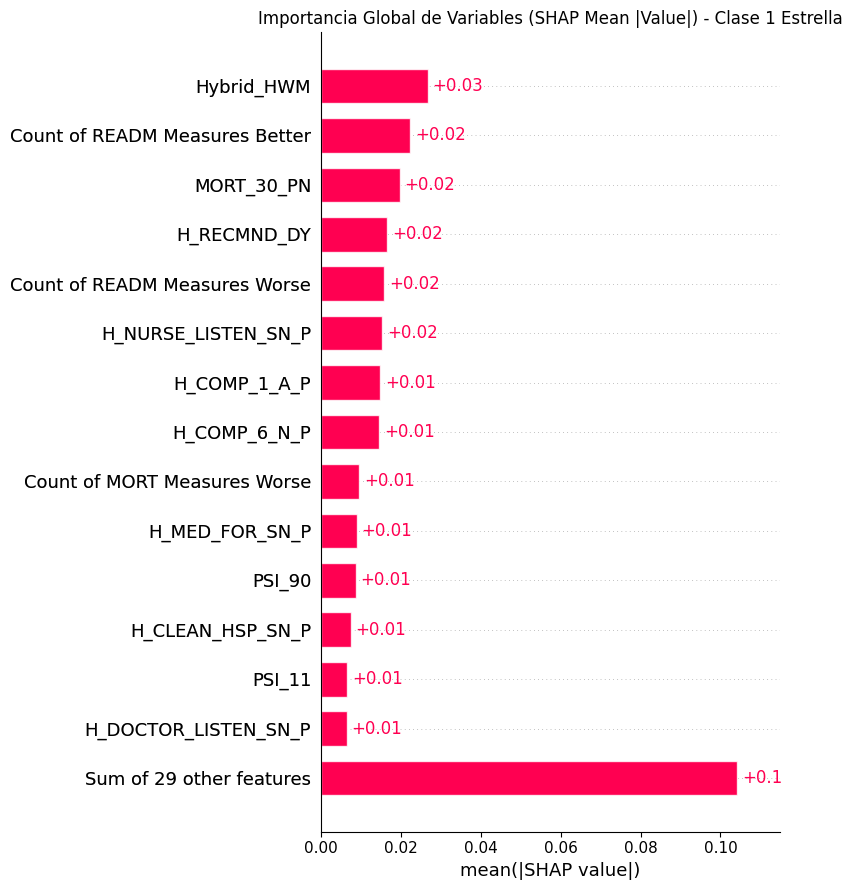

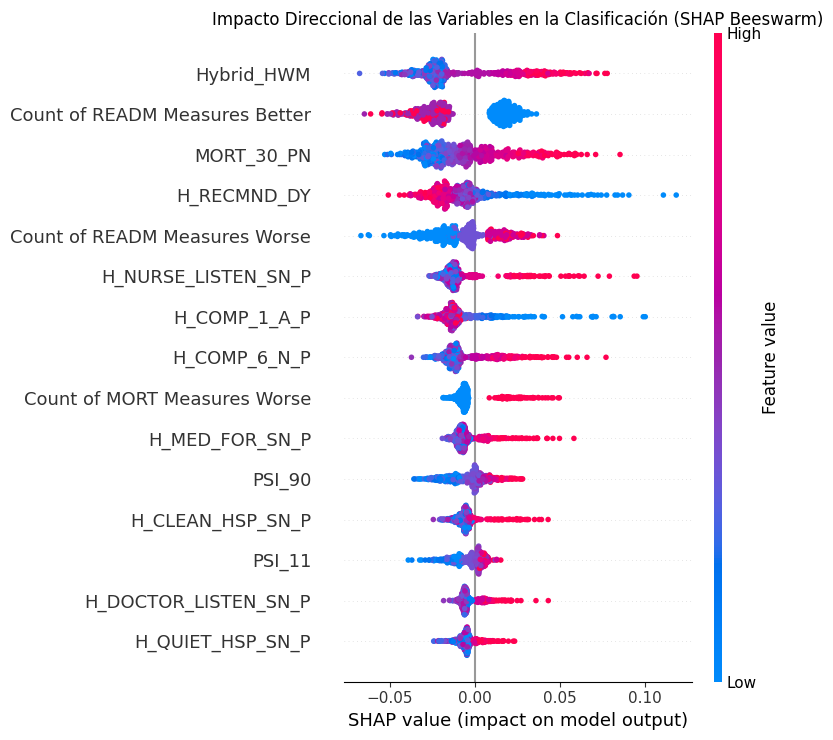

In [28]:
# 1. Crear el explainer específico para árboles sobre el Random Forest entrenado
explainer = shap.TreeExplainer(best_rf)

# 2. Calcular los valores SHAP sobre el conjunto de test (o una muestra representativa)
shap_values = explainer(X_test)

# 3. Gráfico Global de Importancia (SHAP Summary Plot - Bar)
plt.figure(figsize=(10, 8))
shap.plots.bar(shap_values[:, :, 0], max_display=15, show=False)
plt.title(
    "Importancia Global de Variables (SHAP Mean |Value|) - Clase 1 Estrella"
)
plt.tight_layout()
plt.show()

# 4. Gráfico de Impacto y Dirección (SHAP Summary Plot - Summary/Beeswarm)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values.values[:, :, 0], X_test, max_display=15, show=False
)
plt.title(
    "Impacto Direccional de las Variables en la Clasificación (SHAP Beeswarm)"
)
plt.tight_layout()
plt.show()

El análisis direccional (*Beeswarm*) y de importancia media ($|SHAP|$) para la categoría de **1 Estrella** revela los siguientes patrones clave:

1. **Variables Principales de Calidad Asistencial y Reingreso:**
   * **`Hybrid_HWM` y `MORT_30_PN`:** Valores elevados de estas métricas de mortalidad/complicaciones (puntos rojos a la derecha) desplazan positivamente el valor SHAP, incrementando la probabilidad de que el hospital sea clasificado con 1 Estrella.
   * **`Count of READM Measures Better`:** Presenta un comportamiento inverso marcado; valores bajos de reingresos de calidad (puntos azules a la derecha) aumentan la probabilidad de recibir 1 estrella, mientras que valores altos la reducen notablemente.
   * **`Count of READM Measures Worse` y `Count of MORT Measures Worse`:** Cuando el número de indicadores de reingreso o mortalidad deficientes aumenta (puntos rojos a la derecha), se eleva la asignación hacia la categoría más baja.

2. **Indicadores de Experiencia del Paciente (HCAHPS):**
   * **`H_RECMND_DY` y `H_NURSE_LISTEN_SN_P`:** Puntuaciones bajas en la experiencia manifestada por el paciente (puntos azules a la derecha) empujan al modelo a calificar al centro con 1 estrella.
   * **Satisfacción General:** La falta de satisfacción en la comunicación con el personal de enfermería y la baja disposición de los usuarios a recomendar el centro son señales directas de baja calidad percibida.

3. **Métricas de Seguridad del Paciente (PSI):**
   * **`PSI_90` y `PSI_11`:** Indicadores de complicaciones que muestran un impacto positivo hacia 1 estrella cuando registran valores elevados, confirmando que los eventos adversos de seguridad inciden de forma directa en las valoraciones más bajas.

**Conclusión:** El modelo fundamenta sus predicciones negativas combinando resultados clínicos de mortalidad/reingreso con la percepción directa del paciente (HCAHPS), ofreciendo explicaciones coherentes con las normativas de evaluación de calidad sanitaria.

Para completar la interpretación del modelo, analizamos la categoría opuesta: la **Clase 5 Estrellas** (índice 4 del tensor SHAP). Este análisis nos permite identificar qué factores y métricas asistenciales impulsan a un centro hospitalario hacia la máxima calificación de excelencia.

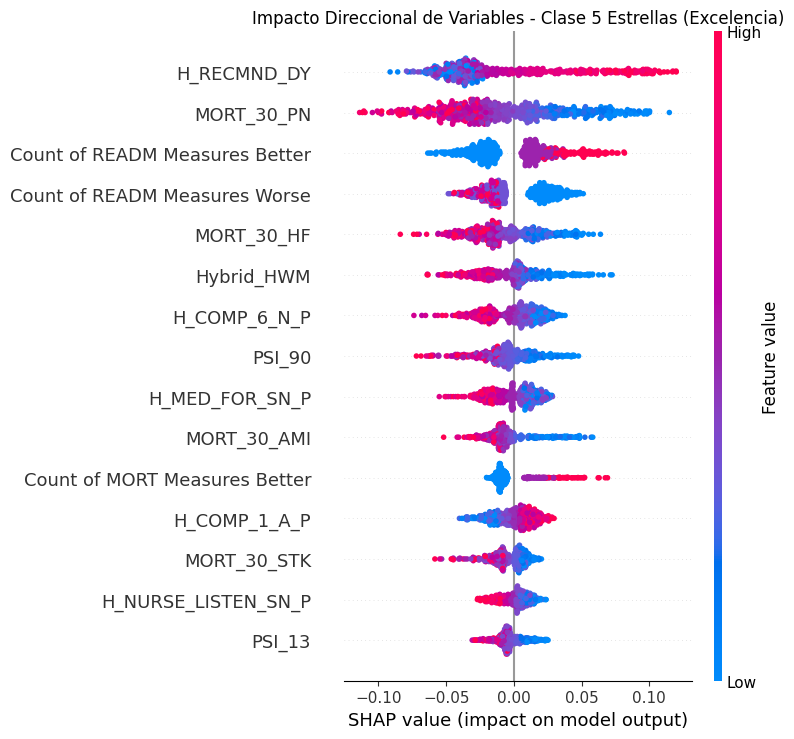

In [29]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values.values[:, :, 4], X_test, max_display=15, show=False
)
plt.title(
    "Impacto Direccional de Variables - Clase 5 Estrellas (Excelencia)"
)
plt.tight_layout()
plt.show()

El gráfico *Beeswarm* para la categoría de excelencia revela una simetría inversa casi perfecta respecto a la Clase 1 Estrella, consolidando los pilares que determinan una calificación máxima:

1. **Predominio de la Experiencia del Paciente (`H_RECMND_DY`):**
   * Es la variable con mayor peso e impacto del modelo. Los valores altos en la disposición a recomendar el hospital (puntos rojos a la derecha) impulsan drásticamente el valor SHAP positivo (hasta $+0,12$), siendo la métrica clave para alcanzar la 5ª estrella.

2. **Bajos Índices de Mortalidad (`MORT_30_PN`, `MORT_30_HF`, `MORT_30_AMI`):**
   * Se observa una tendencia inversa limpia: valores bajos de mortalidad por neumonía, insuficiencia cardíaca e infarto agudo de miocardio (puntos azules a la derecha) incrementan fuertemente la probabilidad de obtener 5 estrellas. Por el contrario, registros altos de mortalidad (puntos rojos a la izquierda) penalizan drásticamente al centro, descartándolo de la excelencia.

3. **Métricas de Reingreso y Desempeño Clínico:**
   * **`Count of READM Measures Better`:** Un recuento elevado de indicadores de reingreso óptimos (puntos rojos a la derecha) aporta un impacto positivo claro.
   * **`Count of READM Measures Worse`:** Los valores bajos o nulos de reingresos deficientes (puntos azules a la derecha) son indispensables para posicionarse en la categoría superior.

4. **Seguridad del Paciente y Satisfacción del Cuidado:**
   * Indicadores de complicaciones como **`PSI_90`**, **`PSI_13`** y métricas de comunicación con el personal de enfermería (**`H_NURSE_LISTEN_SN_P`**) muestran que mantener niveles bajos de eventos adversos y altas puntuaciones de atención favorece sistemáticamente la asignación de la máxima puntuación.

**Conclusión:** La obtención de **5 Estrellas** requiere un desempeño dual impecable: **excelencia clínica** (bajas tasas de mortalidad y complicaciones) junto con una **percepción de satisfacción sobresaliente** por parte de los pacientes.

# Productivización del modelo

Para trasladar el modelo predictivo desde el entorno de experimentación (*Jupyter Notebook*) a un artefacto funcional accesible para la toma de decisiones directivas, se implementa una aplicación web con **Streamlit**.

In [30]:
!pip install -q streamlit shap pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 133.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 122.2 MB/s eta 0:00:00


Para asegurar la reproducibilidad e integridad de las predicciones en el entorno de producción, es necesario serializar no solo el estimador entrenado, sino también la estructura de datos y una línea base (*baseline*) del dominio hospitalario.

* **Modelo Optimizado (`modelo_rf.pkl`):** Objeto `RandomForestClassifier` calibrado.
* **Nombres de Variables (`feature_names.pkl`):** Lista ordenada de las características utilizadas durante el entrenamiento para evitar desalineaciones en la matriz de entrada.
* **Vector de Mediana Hospitalaria (`hospital_promedio.pkl`):** Representa las métricas de un "hospital promedio" (obtenido mediante `X_train.median()`). Esto resuelve el problema de las variables no modificadas en la interfaz interactiva, evitando imputar ceros arbitrarios que descalibren el modelo.
* **Escalador (`scaler.pkl`):** Objeto de estandarización para aplicar la misma transformación en caso de ser requerida por el pipeline.

In [31]:
import joblib

# Guardar el modelo entrenado
joblib.dump(best_rf, "modelo_rf.pkl")

# Guardar los nombres de las columnas
joblib.dump(X_train.columns.tolist(), "feature_names.pkl")

# Guardar el hospital promedio (mediana de X_train) para rellenar las variables no modificadas
hospital_promedio = X_train.median()
joblib.dump(hospital_promedio, "hospital_promedio.pkl")

# Opcional: Guardar el scaler si tu pipeline usa StandardScaler explícito sobre X_train
try:
    joblib.dump(scaler, "scaler.pkl")
except NameError:
    joblib.dump(None, "scaler.pkl")

print("✅ Artefactos guardados con los valores base reales de X_train.")

✅ Artefactos guardados con los valores base reales de X_train.


Mediante el comando `%%writefile app.py`, generamos el código fuente de la aplicación interactiva. La arquitectura del cuadro de mando incluye:

1. **Gestión de Memoria y Caché (`@st.cache_resource`):** Carga los artefactos `.pkl` una sola vez en memoria para optimizar el tiempo de respuesta.
2. **Panel Lateral de Control (Inputs en Escala Real):** Organiza los indicadores clínicos más determinantes mediante menús desplegables (*expanders*) y deslizadores (*sliders*), precargando como valor por defecto la mediana real del dataset.
3. **Reconstrucción del Vector de Características:** Toma la mediana base (`hospital_promedio`) y actualiza exclusivamente los parámetros modificados por el usuario, manteniendo la coherencia probabilística de las $N$ variables restantes.
4. **Motor de Inferencia y Módulo SHAP Local:** Realiza la predicción ordinal (1 a 5 estrellas), calcula la distribución probabilística por clase y genera dinámicamente un gráfico de tipo *Waterfall* mediante `TreeExplainer` para transparentar la contribución local de cada indicador sobre el diagnóstico final.

In [32]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

st.set_page_config(page_title="Cuadro de Mando - Calidad Hospitalaria", page_icon="🏥", layout="wide")

@st.cache_resource
def load_artifacts():
    model = joblib.load("modelo_rf.pkl")
    feature_names = joblib.load("feature_names.pkl")
    hospital_promedio = joblib.load("hospital_promedio.pkl")
    scaler = joblib.load("scaler.pkl")
    return model, feature_names, hospital_promedio, scaler

model, feature_names, hospital_promedio, scaler = load_artifacts()

st.title("🏥 Cuadro de Mando Estratégico: Simulador de Calidad Hospitalaria")
st.markdown("Herramienta de simulación predictiva e interpretabilidad SHAP local sobre la escala real de los datos.")

col_inputs, col_results = st.columns([1.2, 1.8], gap="large")

with col_inputs:
    st.header("📋 Indicadores del Centro")

    def get_default(col, default_val):
        return float(hospital_promedio[col]) if col in hospital_promedio else default_val

    # --- 1. EXPERIENCIA DEL PACIENTE (HCAHPS) ---
    with st.expander("⭐ Experiencia del Paciente (HCAHPS)", expanded=True):
        h_recmnd = st.slider(
            "Pacientes que recomendarían el hospital (%)", 0.0, 100.0,
            get_default('H_RECMND_DY', 72.0)
        )
        h_nurse_listen = st.slider(
            "Comunicación con enfermería (%)", 0.0, 100.0,
            get_default('H_NURSE_LISTEN_SN_P', 78.0)
        )
        h_comp_1 = st.slider(
            "Comunicación con médicos (%)", 0.0, 100.0,
            get_default('H_COMP_1_A_P', 80.0)
        )

    # --- 2. REINGRESOS ---
    with st.expander("🔄 Control de Reingresos no Programados", expanded=True):
        readm_better = st.number_input(
            "Nº de procesos con reingresos MEJORES que la media", 0, 15,
            int(get_default('Count of READM Measures Better', 2))
        )
        readm_worse = st.number_input(
            "Nº de procesos con reingresos PEORES que la media", 0, 15,
            int(get_default('Count of READM Measures Worse', 1))
        )

    # --- 3. MORTALIDAD Y RESULTADOS CLÍNICOS ---
    with st.expander("🩺 Mortalidad a 30 días", expanded=True):
        mort_pn = st.slider(
            "Tasa de mortalidad por Neumonía (%)", 0.0, 30.0,
            get_default('MORT_30_PN', 14.5)
        )
        mort_hf = st.slider(
            "Tasa de mortalidad por Insuficiencia Cardíaca (%)", 0.0, 30.0,
            get_default('MORT_30_HF', 12.0)
        )
        mort_worse = st.number_input(
            "Nº de procesos con mortalidad PEOR que la media", 0, 10,
            int(get_default('Count of MORT Measures Worse', 0))
        )

    # --- 4. SEGURIDAD DEL PACIENTE (PSI) Y RIESGO ---
    with st.expander("🛡️ Seguridad del Paciente e Índices de Riesgo", expanded=True):
        psi_90 = st.slider(
            "Índice de Complicaciones y Seguridad (PSI_90)", 0.0, 5.0,
            get_default('PSI_90', 1.0), step=0.05
        )
        hybrid_hwm = st.slider(
            "Índice Combinado de Riesgo Asistencial (Hybrid_HWM)", 0.0, 5.0,
            get_default('Hybrid_HWM', 1.1), step=0.1
        )

    # 1. Cargar el hospital promedio como base
    input_df = pd.DataFrame([hospital_promedio], columns=feature_names)

    # 2. Asignar los valores introducidos por el usuario en las variables presentes en el dataset
    vars_to_update = {
        'H_RECMND_DY': h_recmnd,
        'H_NURSE_LISTEN_SN_P': h_nurse_listen,
        'H_COMP_1_A_P': h_comp_1,
        'Count of READM Measures Better': readm_better,
        'Count of READM Measures Worse': readm_worse,
        'MORT_30_PN': mort_pn,
        'MORT_30_HF': mort_hf,
        'Count of MORT Measures Worse': mort_worse,
        'PSI_90': psi_90,
        'Hybrid_HWM': hybrid_hwm
    }

    for col, val in vars_to_update.items():
        if col in input_df.columns:
            input_df[col] = val

    # 3. Aplicar escalado si corresponde
    if scaler is not None:
        scaled_data = scaler.transform(input_df)
        final_df = pd.DataFrame(scaled_data, columns=feature_names)
    else:
        final_df = input_df.copy()

    st.markdown("---")
    btn_predict = st.button("📊 Generar Diagnóstico de Calidad", type="primary", use_container_width=True)

with col_results:
    st.header("📈 Diagnóstico y Análisis Estratégico")

    if btn_predict:
        prediction = int(model.predict(final_df)[0])
        probabilities = model.predict_proba(final_df)[0]

        st.subheader("Calificación Predicha para el Centro:")
        if prediction >= 4:
            st.success(f"### ⭐⭐⭐⭐⭐ {prediction} Estrellas (Nivel Alto)")
        elif prediction == 3:
            st.warning(f"### ⭐⭐⭐ {prediction} Estrellas (Nivel Medio)")
        else:
            st.error(f"### ⭐ {prediction} Estrella(s) (Nivel de Riesgo)")

        st.write("**Distribución de Probabilidad:**")
        prob_df = pd.DataFrame({
            'Categoría': [f"{i} Estrella(s)" for i in range(1, 6)],
            'Probabilidad': [f"{p*100:.1f}%" for p in probabilities]
        })
        st.dataframe(prob_df.T, use_container_width=True)

        st.markdown("---")
        st.subheader("🔍 Factores Determinantes (SHAP Local)")

        explainer = shap.TreeExplainer(model)
        shap_values = explainer(final_df)

        classes_list = list(model.classes_)
        class_idx = classes_list.index(prediction) if prediction in classes_list else 0

        fig, ax = plt.subplots(figsize=(9, 4.5))
        if len(shap_values.shape) == 3:
            shap.plots.waterfall(shap_values[0, :, class_idx], max_display=6, show=False)
        else:
            shap.plots.waterfall(shap_values[0], max_display=6, show=False)

        plt.tight_layout()
        st.pyplot(fig)

Writing app.py


Para exponer la aplicación desde el entorno de ejecución en la nube (como Google Colab o servidores remotos) hacia una URL accesible desde cualquier navegador web:

1. **Instalación de Binary Daemon (`cloudflared`):** Descarga e instala el binario oficial de Cloudflare Tunnel.
2. **Ejecución Asíncrona de Streamlit:** Lanza el proceso de `app.py` en segundo plano redireccionando la salida a `streamlit.log`.
3. **Publicación del Túnel:** Crea un puente HTTPS hacia el puerto interno `8501`, generando un enlace público seguro de prueba.

In [ ]:
# 1. Instalar el conector de Cloudflare
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb &> /dev/null

# 2. Iniciar Streamlit en segundo plano
!nohup streamlit run app.py > streamlit.log 2>&1 &

# 3. Abrir el túnel estable de Cloudflare
!cloudflared tunnel --url http://localhost:8501

2026-09-07T18:02:29Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-07T18:02:29Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-07T18:02:38Z INF +--------------------------------------------------------------------------------------------+
2026-09-07T18:02:38Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-07T18:02:38Z INF |  https://generation-glossary-consist-atlas.trycloudfla

El simulador desplegado demuestra una respuesta congruente y sensible frente a las variaciones en las métricas de gestión hospitalaria

Exportamos el notebook a html

In [ ]:
!jupyter nbconvert --to html /content/drive/MyDrive/TFM/tfm_notebook_diego_sosa.ipynb

[NbConvertApp] Converting notebook /content/drive/MyDrive/TFM/tfm_notebook_diego_sosa.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 1111514 bytes to /content/drive/MyDrive/TFM/tfm_notebook_diego_sosa.html
